fig 2.b

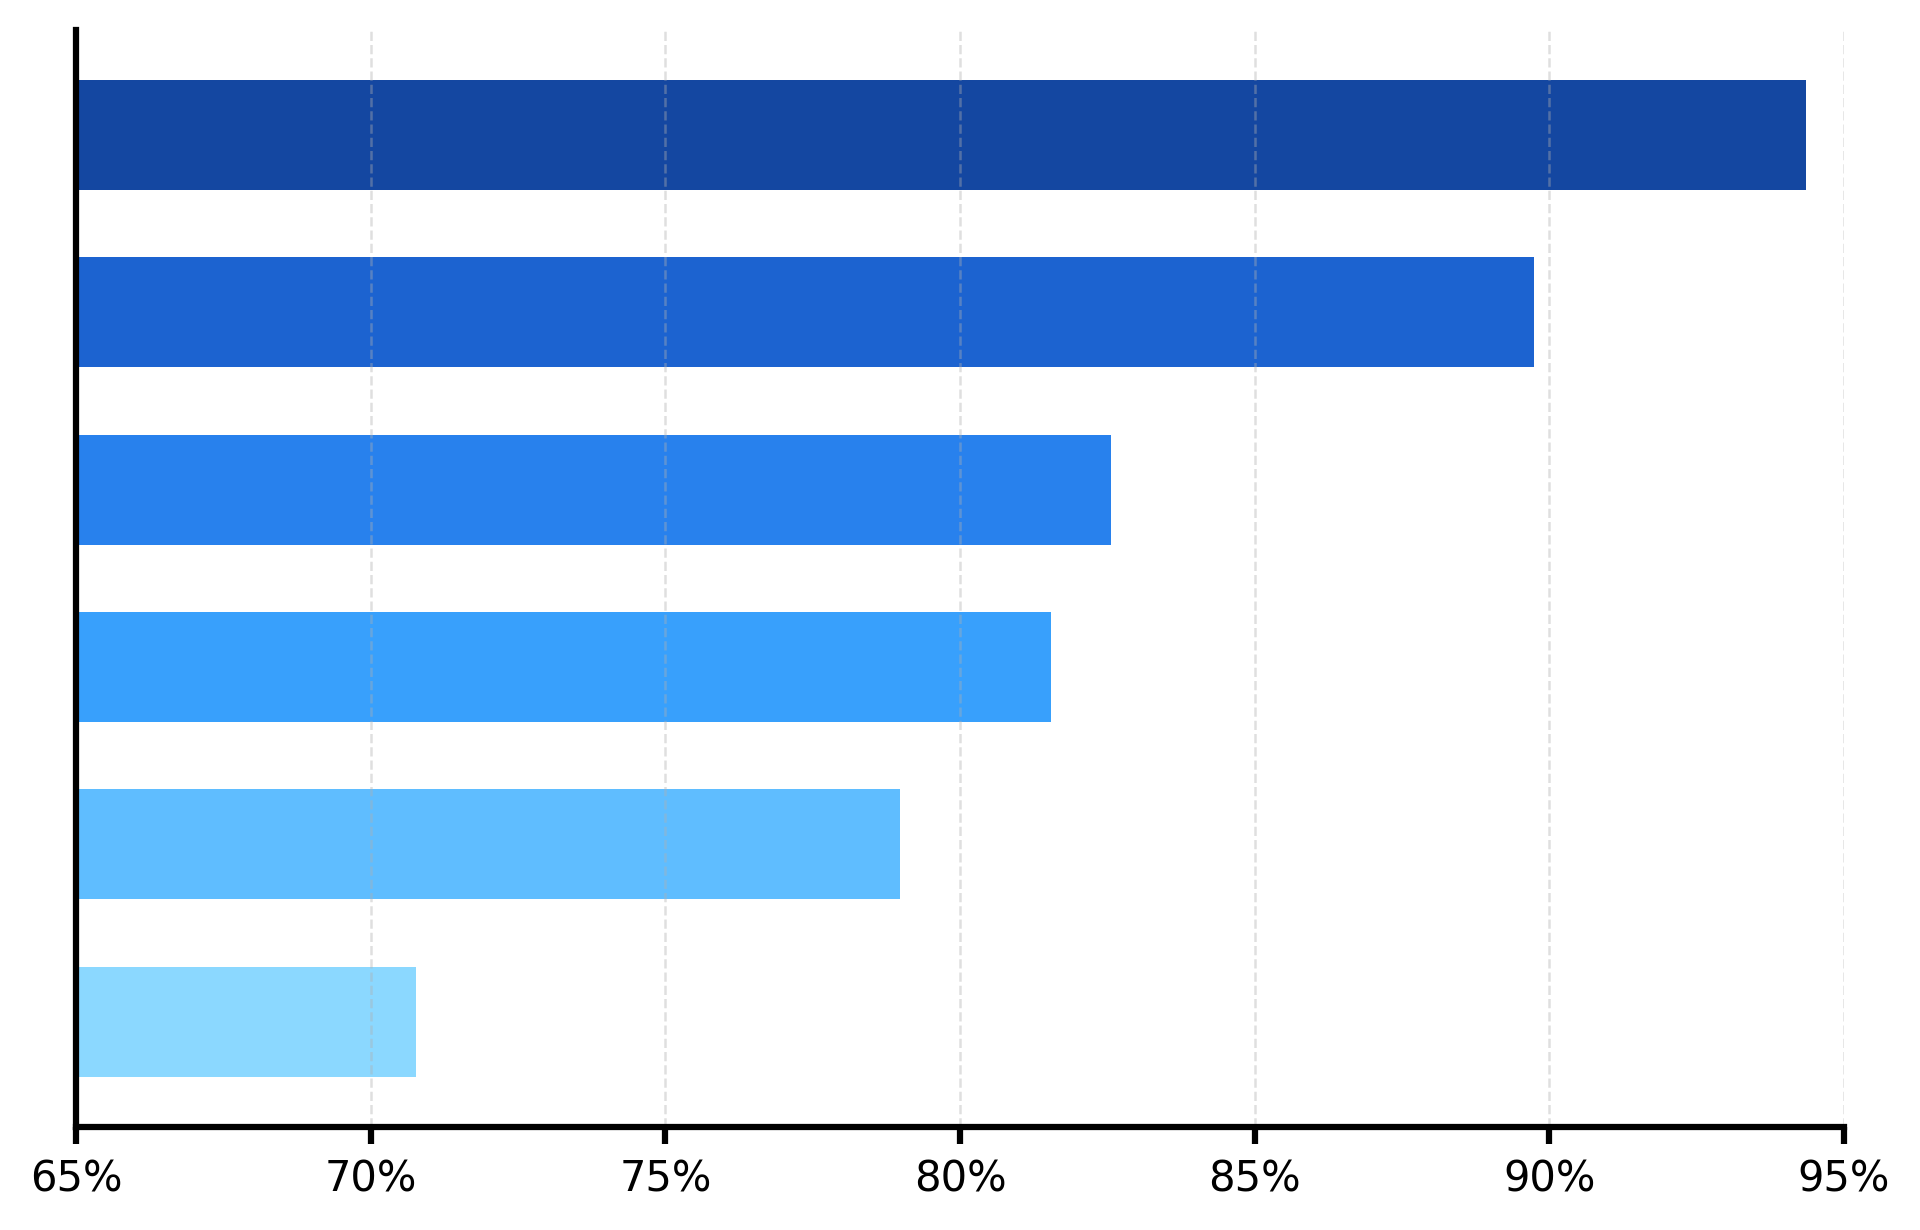

In [ ]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


# =========================
# 1. Data
# =========================
data = {
    "Field": [
        "Cell type",
        "Interphase",
        "Anode",
        "Electrolyte",
        "Cathode",
        "Additive",
    ],
    "Accuracy": [
        0.70769,
        0.78974,
        0.81538,
        0.82564,
        0.89744,
        0.94359,
    ],
}

df = pd.DataFrame(data)

# 按准确率升序排列
df = df.sort_values("Accuracy", ascending=True).reset_index(drop=True)

# 如果想按降序排列，改成：
# df = df.sort_values("Accuracy", ascending=False).reset_index(drop=True)


# =========================
# 2. DeepSeek-like gradient colors
# =========================
deepseek_cmap = LinearSegmentedColormap.from_list(
    "deepseek_blue",
    [
        "#D8F3FF",
        "#8BD8FF",
        "#3BA7FF",
        "#1F6FE5",
        "#123E91",
    ],
)

colors = deepseek_cmap(np.linspace(0.25, 0.95, len(df)))


# =========================
# 3. Plot
# =========================
plt.figure(figsize=(6.5, 4.2), dpi=300)

plt.barh(
    df["Field"],
    df["Accuracy"],
    color=colors,
    linewidth=0.8,
    height=0.62,
)


# =========================
# 4. Style
# =========================
plt.xlim(0.65, 0.95)

xticks = np.arange(0.65, 0.96, 0.05)
# plt.xticks([])
plt.xticks(xticks, [f"{x * 100:.0f}%" for x in xticks], fontsize=10)
# plt.yticks(fontsize=11)
plt.yticks([])

plt.grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

# plt.xticks([])

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 坐标轴线加粗
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)

# 刻度线加粗
ax.tick_params(axis="x", width=1.5, length=4)
ax.tick_params(axis="y", width=1.5, length=4)

plt.tight_layout()


# =========================
# 5. Save
# =========================
plt.savefig("./save_figs/fig2_b.svg", dpi=600, bbox_inches="tight")
plt.show()

fig 2.c

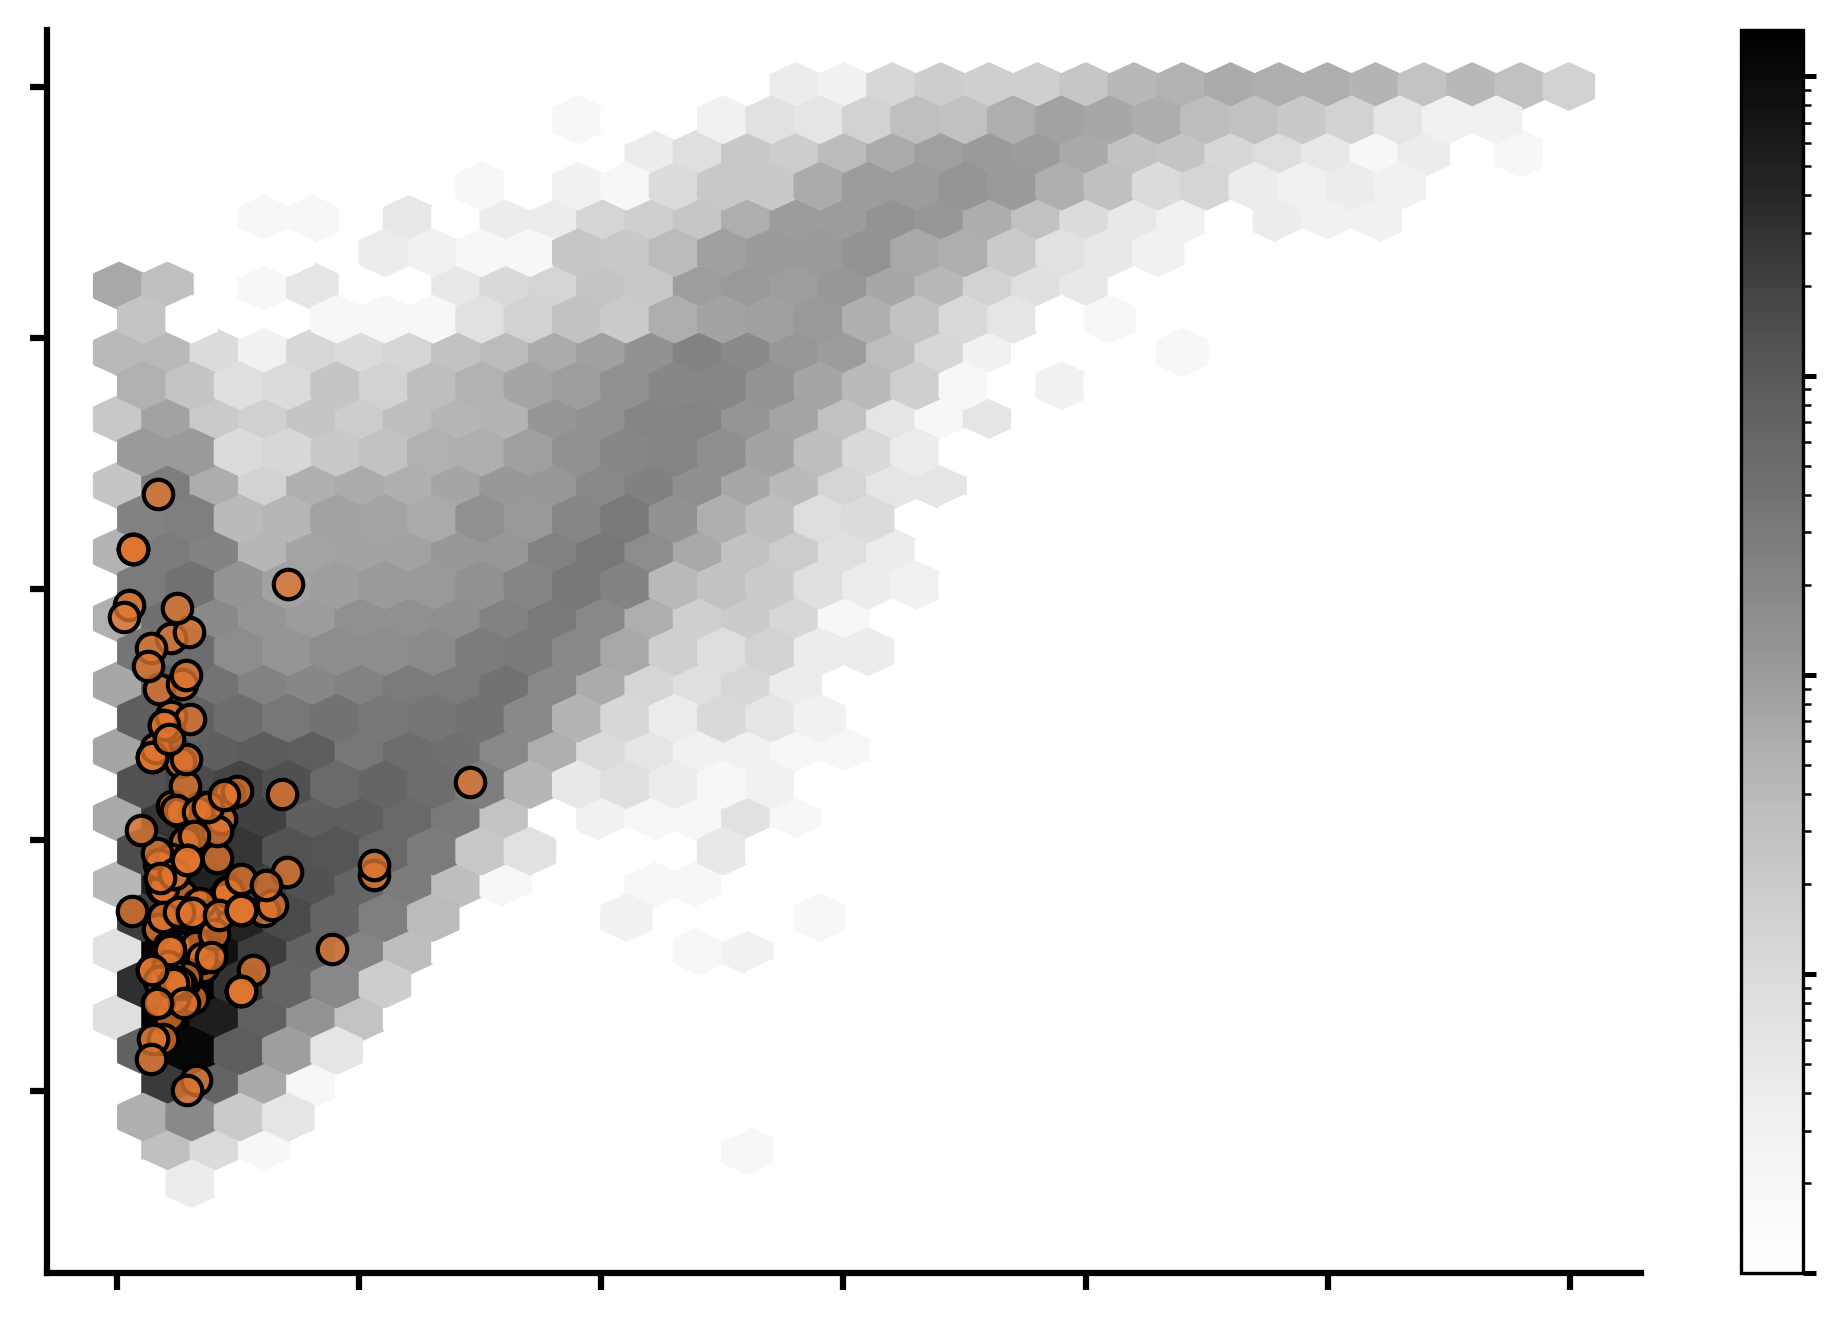

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os


# ======================
# load data
# ======================

with open('/home/hwx/python_project/test/Boron/V3/plot_data/mass_full.pkl', 'rb') as f:
    mass_full = np.array(pickle.load(f))

with open('/home/hwx/python_project/test/Boron/V3/plot_data/sa_score_full.pkl', 'rb') as f:
    sa_score_full = np.array(pickle.load(f))

with open('/home/hwx/python_project/test/Boron/V3/plot_data/mass_partial.pkl', 'rb') as f:
    mass_partial = np.array(pickle.load(f))

with open('/home/hwx/python_project/test/Boron/V3/plot_data/sa_score_partial.pkl', 'rb') as f:
    sa_score_partial = np.array(pickle.load(f))

select_idx = np.where(mass_partial <= 6000)[0]
mass_partial = mass_partial[select_idx]
sa_score_partial = sa_score_partial[select_idx]


# ======================
# plot
# ======================
plt.rcParams['font.family'] = 'Arial'

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)

# hexbin
hb = ax.hexbin(
    mass_partial,
    sa_score_partial,
    gridsize=30,
    cmap='Grays',
    bins='log',
    mincnt=1
)

# colorbar：保留色条，但删除文字和刻度数字
cb = fig.colorbar(hb, ax=ax)
cb.set_label("")
cb.ax.set_yticklabels([])
cb.ax.tick_params(
    labelleft=False,
    labelright=False,
    left=False,
    right=True,
    width=1.2,
    length=3
)

# scatter
ax.scatter(
    mass_full,
    sa_score_full,
    color="#DF752FC7",
    s=50,
    marker='o',
    edgecolors='black',
    linewidth=1
)

# 删除 x/y 轴标题
ax.set_xlabel("")
ax.set_ylabel("")

# 隐藏刻度文字，但保留刻度位置
ax.set_xticklabels([])
ax.set_yticklabels([])

# 保留 x/y 轴刻度线，但隐藏刻度值
ax.tick_params(
    axis="both",
    which="both",
    labelbottom=False,
    labelleft=False,
    bottom=True,
    left=True,
    width=1.5,
    length=4
)

# 坐标轴线加粗
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)

# 删除上、右边框
sns.despine(ax=ax)

os.makedirs("./save_figs", exist_ok=True)
plt.tight_layout()
plt.savefig("./save_figs/fig2_c.svg", dpi=600, bbox_inches="tight")
plt.show()

fig 2.d

In [60]:
import pickle


data_path = '/home/hwx/python_project/test/Boron/data/all_data.pkl'
with open(data_path, 'rb') as f:
    all_data = pickle.load(f)

positive_samples = all_data[:126] # number of positive samples
unlabeled_samples = all_data[126:]

print(positive_samples[0])

Data(x=[16, 79], edge_index=[2, 30], edge_attr=[30, 16], id=0, n_nodes=16, n_edges=30)


Atoms
positive min: 2 negative count: 0
unlabeled min: 1 negative count: 0
Bonds
positive min: 1.0 negative count: 0
unlabeled min: 0.0 negative count: 0
Average degree
positive min: 0.8571428571428571 negative count: 0
unlabeled min: 0.0 negative count: 0
Graph density
positive min: 0.019999999999979798 negative count: 0
unlabeled min: 0.0 negative count: 0


/tmp/ipykernel_418998/27724772.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.02, 1, 0.98])


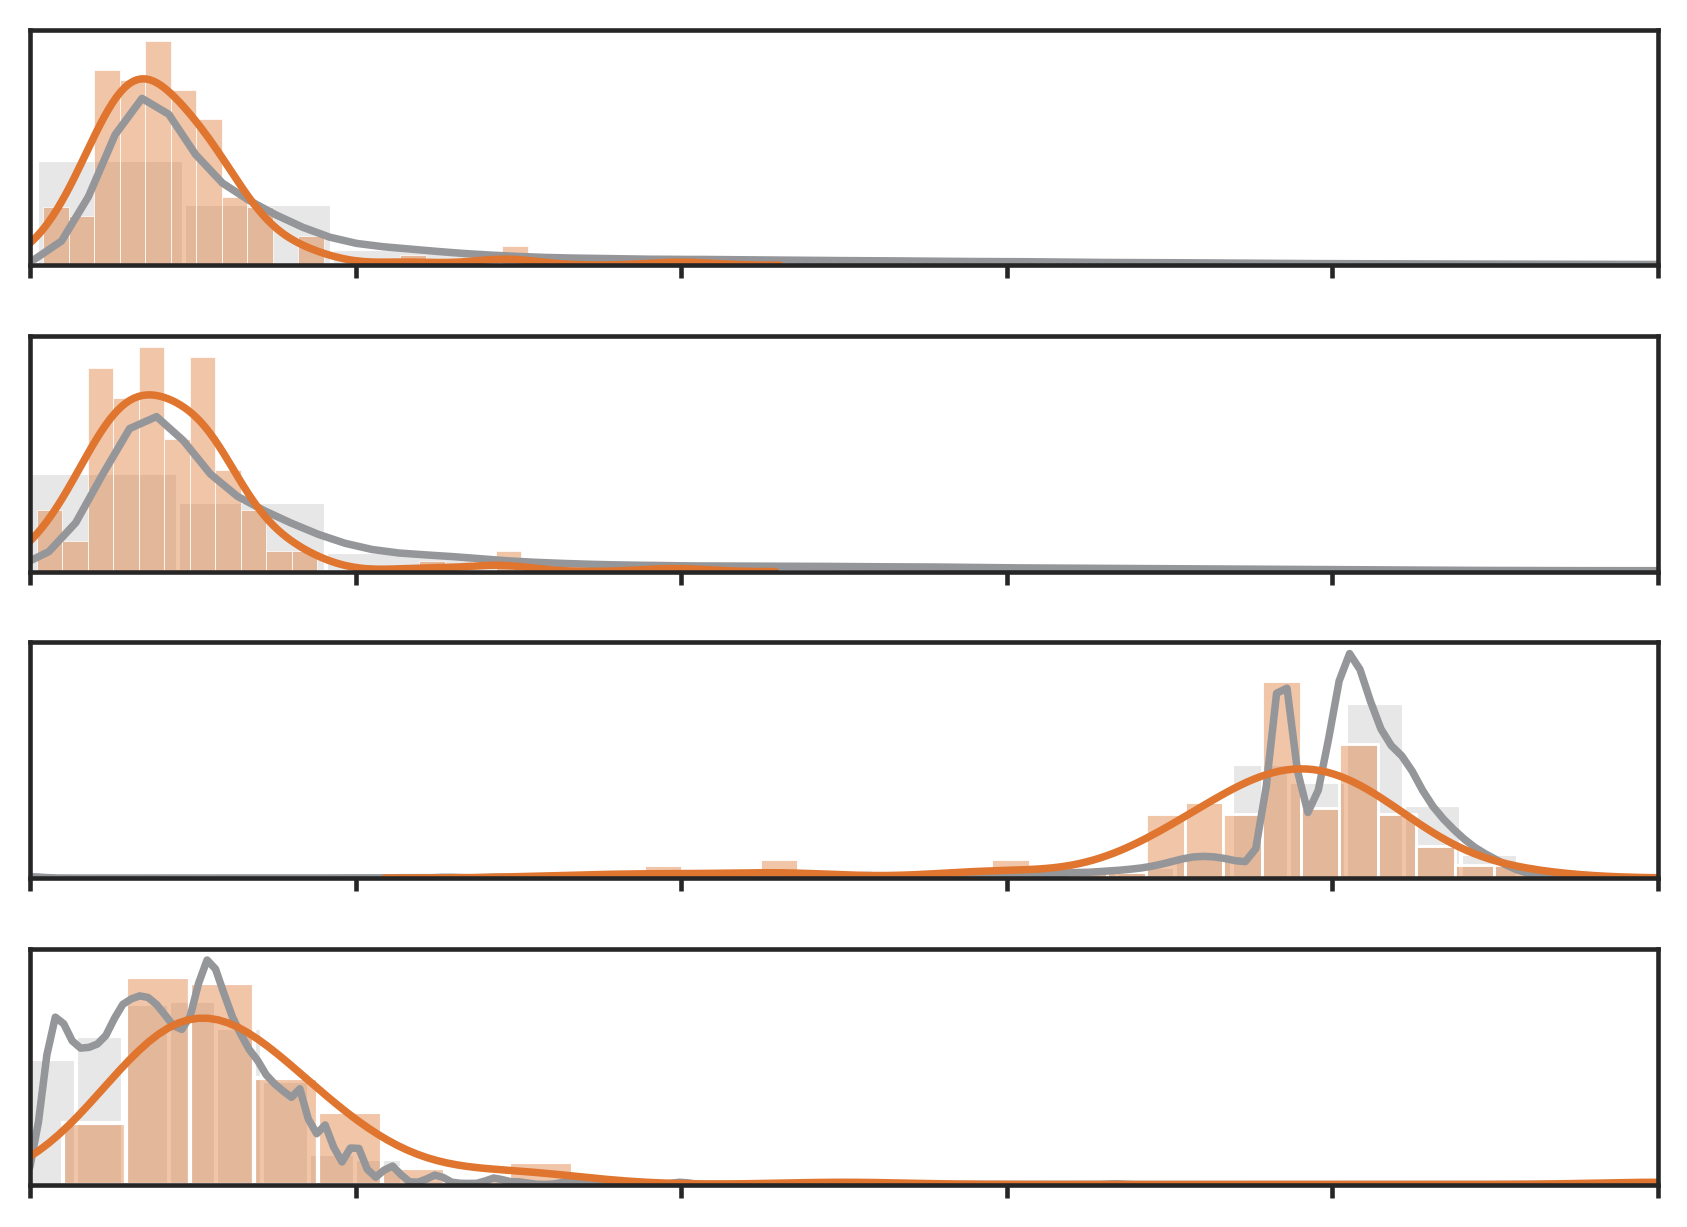

In [66]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. Extract graph-level properties
# ============================================================

def get_graph_level_properties(dataset, edge_is_bidirectional=True):
    num_atoms = []
    num_bonds = []
    avg_degree = []
    graph_density = []

    for data in dataset:
        if hasattr(data, "n_nodes"):
            n = int(data.n_nodes)
        else:
            n = int(data.x.shape[0])

        if hasattr(data, "n_edges"):
            e_raw = int(data.n_edges)
        elif hasattr(data, "edge_index"):
            e_raw = int(data.edge_index.shape[1])
        else:
            raise AttributeError("Data object must have n_edges or edge_index.")

        if edge_is_bidirectional:
            e = e_raw / 2.0
        else:
            e = e_raw

        num_atoms.append(n)
        num_bonds.append(e)
        avg_degree.append(2.0 * e / max(n, 1))

        density = 2.0 * e / (n * (n - 1) + 1e-8)
        graph_density.append(density)

    props = {
        "Atoms": np.array(num_atoms),
        "Bonds": np.array(num_bonds),
        "Average degree": np.array(avg_degree),
        "Graph density": np.array(graph_density),
    }

    return props


positive_props = get_graph_level_properties(
    positive_samples,
    edge_is_bidirectional=True
)

unlabeled_props = get_graph_level_properties(
    unlabeled_samples,
    edge_is_bidirectional=True
)


# ============================================================
# 2. Plot settings
# ============================================================

plt.rcParams["font.family"] = "Arial"
sns.set_theme(style="white")

positive_color = "#DF752F"
unlabeled_color = "#949699"

metrics = [
    "Atoms",
    "Bonds",
    "Average degree",
    "Graph density",
]

# ============================================================
# 你可以在这里手动控制每个横坐标范围
# ============================================================

xlim_dict = {
    "Atoms": (0, 250),
    "Bonds": (0, 250),
    "Average degree": (0.0, 2.6),
    "Graph density": (0.0, 1.0),
}

xticks_dict = {
    "Atoms": np.arange(0, 251, 20),
    "Bonds": np.arange(0, 251, 30),
    "Average degree": np.arange(0.0, 2.61, 0.4),
    "Graph density": np.arange(0.0, 1.01, 0.10),
}

num_xticks = 6

xticks_dict = {
    metric: np.linspace(xlim_dict[metric][0], xlim_dict[metric][1], num_xticks)
    for metric in metrics
}


fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(7, 5),
    dpi=300,
    gridspec_kw={
        "height_ratios": [1, 1, 1, 1],
        "hspace": 0.3
    }
)


# ============================================================
# 3. Plot stacked distributions
# ============================================================

for metric in metrics:
    x_pos = positive_props[metric]
    x_unl = unlabeled_props[metric]

    print("=" * 50)
    print(metric)
    print("positive min:", np.min(x_pos), "negative count:", np.sum(x_pos < 0))
    print("unlabeled min:", np.min(x_unl), "negative count:", np.sum(x_unl < 0))

for i, (ax, metric) in enumerate(zip(axes, metrics)):
    x_pos = positive_props[metric]
    x_unl = unlabeled_props[metric]

    x_pos = x_pos[np.isfinite(x_pos)]
    x_unl = x_unl[np.isfinite(x_unl)]

    sns.histplot(
        x_unl,
        bins=35,
        stat="density",
        color=unlabeled_color,
        alpha=0.22,
        edgecolor=None,
        ax=ax,
    )

    sns.histplot(
        x_pos,
        bins=25,
        stat="density",
        color=positive_color,
        alpha=0.42,
        edgecolor=None,
        ax=ax,
    )

    if len(np.unique(x_unl)) > 1:
        sns.kdeplot(
            x_unl,
            color=unlabeled_color,
            linewidth=1.8,
            ax=ax,
            clip_on=True
        )

    if len(np.unique(x_pos)) > 1:
        sns.kdeplot(
            x_pos,
            color=positive_color,
            linewidth=1.8,
            ax=ax,
            clip_on=True
        )

    # 手动设置每个子图的横坐标范围和刻度
    ax.set_xlim(xlim_dict[metric])
    ax.set_xticks(xticks_dict[metric])

    # 删除 y 轴和 label
    ax.set_ylabel("")
    ax.set_yticks([])
    ax.tick_params(
        axis="y",
        left=False,
        labelleft=False,
        length=0
    )

    # 不显示 x 轴标题，但保留 x 轴刻度值
    ax.set_xlabel("")
    ax.tick_params(
        axis="x",
        labelsize=9,
        width=1.1,
        length=3,
        labelbottom=False,
        bottom=True
    )

    for label in ax.get_xticklabels():
        label.set_fontweight("bold")

    # 保留四周边框
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)
    ax.spines["top"].set_linewidth(1.1)
    ax.spines["right"].set_linewidth(1.1)


# ============================================================
# 4. Save
# ============================================================

os.makedirs("./save_figs", exist_ok=True)

plt.tight_layout(rect=[0.02, 0.02, 1, 0.98])
plt.savefig("./save_figs/fig2_d.svg", dpi=600, bbox_inches="tight")
plt.show()

fig 2.e

Node positive shape: (2720, 79)
Node unlabeled shape: (7409712, 79)
Node feature dimension: 79
Selected top-20 node feature dims: [67 68 65 59  0 74 64 73 60  4 46 45 52 44  2]

Top 20 node feature shifts:
   feature  positive  unlabeled     delta  abs_delta
0      N67  0.120014   0.072501  0.047514   0.047514
1      N68  0.093156   0.050265  0.042891   0.042891
2      N65  0.027862   0.059998 -0.032136   0.032136
3      N59  0.049390   0.076655 -0.027265   0.027265
4       N0  0.059202   0.085935 -0.026734   0.026734
5      N74  0.017222   0.043892 -0.026669   0.026669
6      N64  0.045871   0.070997 -0.025126   0.025126
7      N73  0.076631   0.053038  0.023593   0.023593
8      N60  0.060319   0.039323  0.020996   0.020996
9       N4  0.020410   0.003511  0.016899   0.016899
10     N46  0.023639   0.035547 -0.011907   0.011907
11     N45  0.043759   0.053599 -0.009840   0.009840
12     N52  0.106935   0.116355 -0.009419   0.009419
13     N44  0.034320   0.025159  0.009162   0.009162

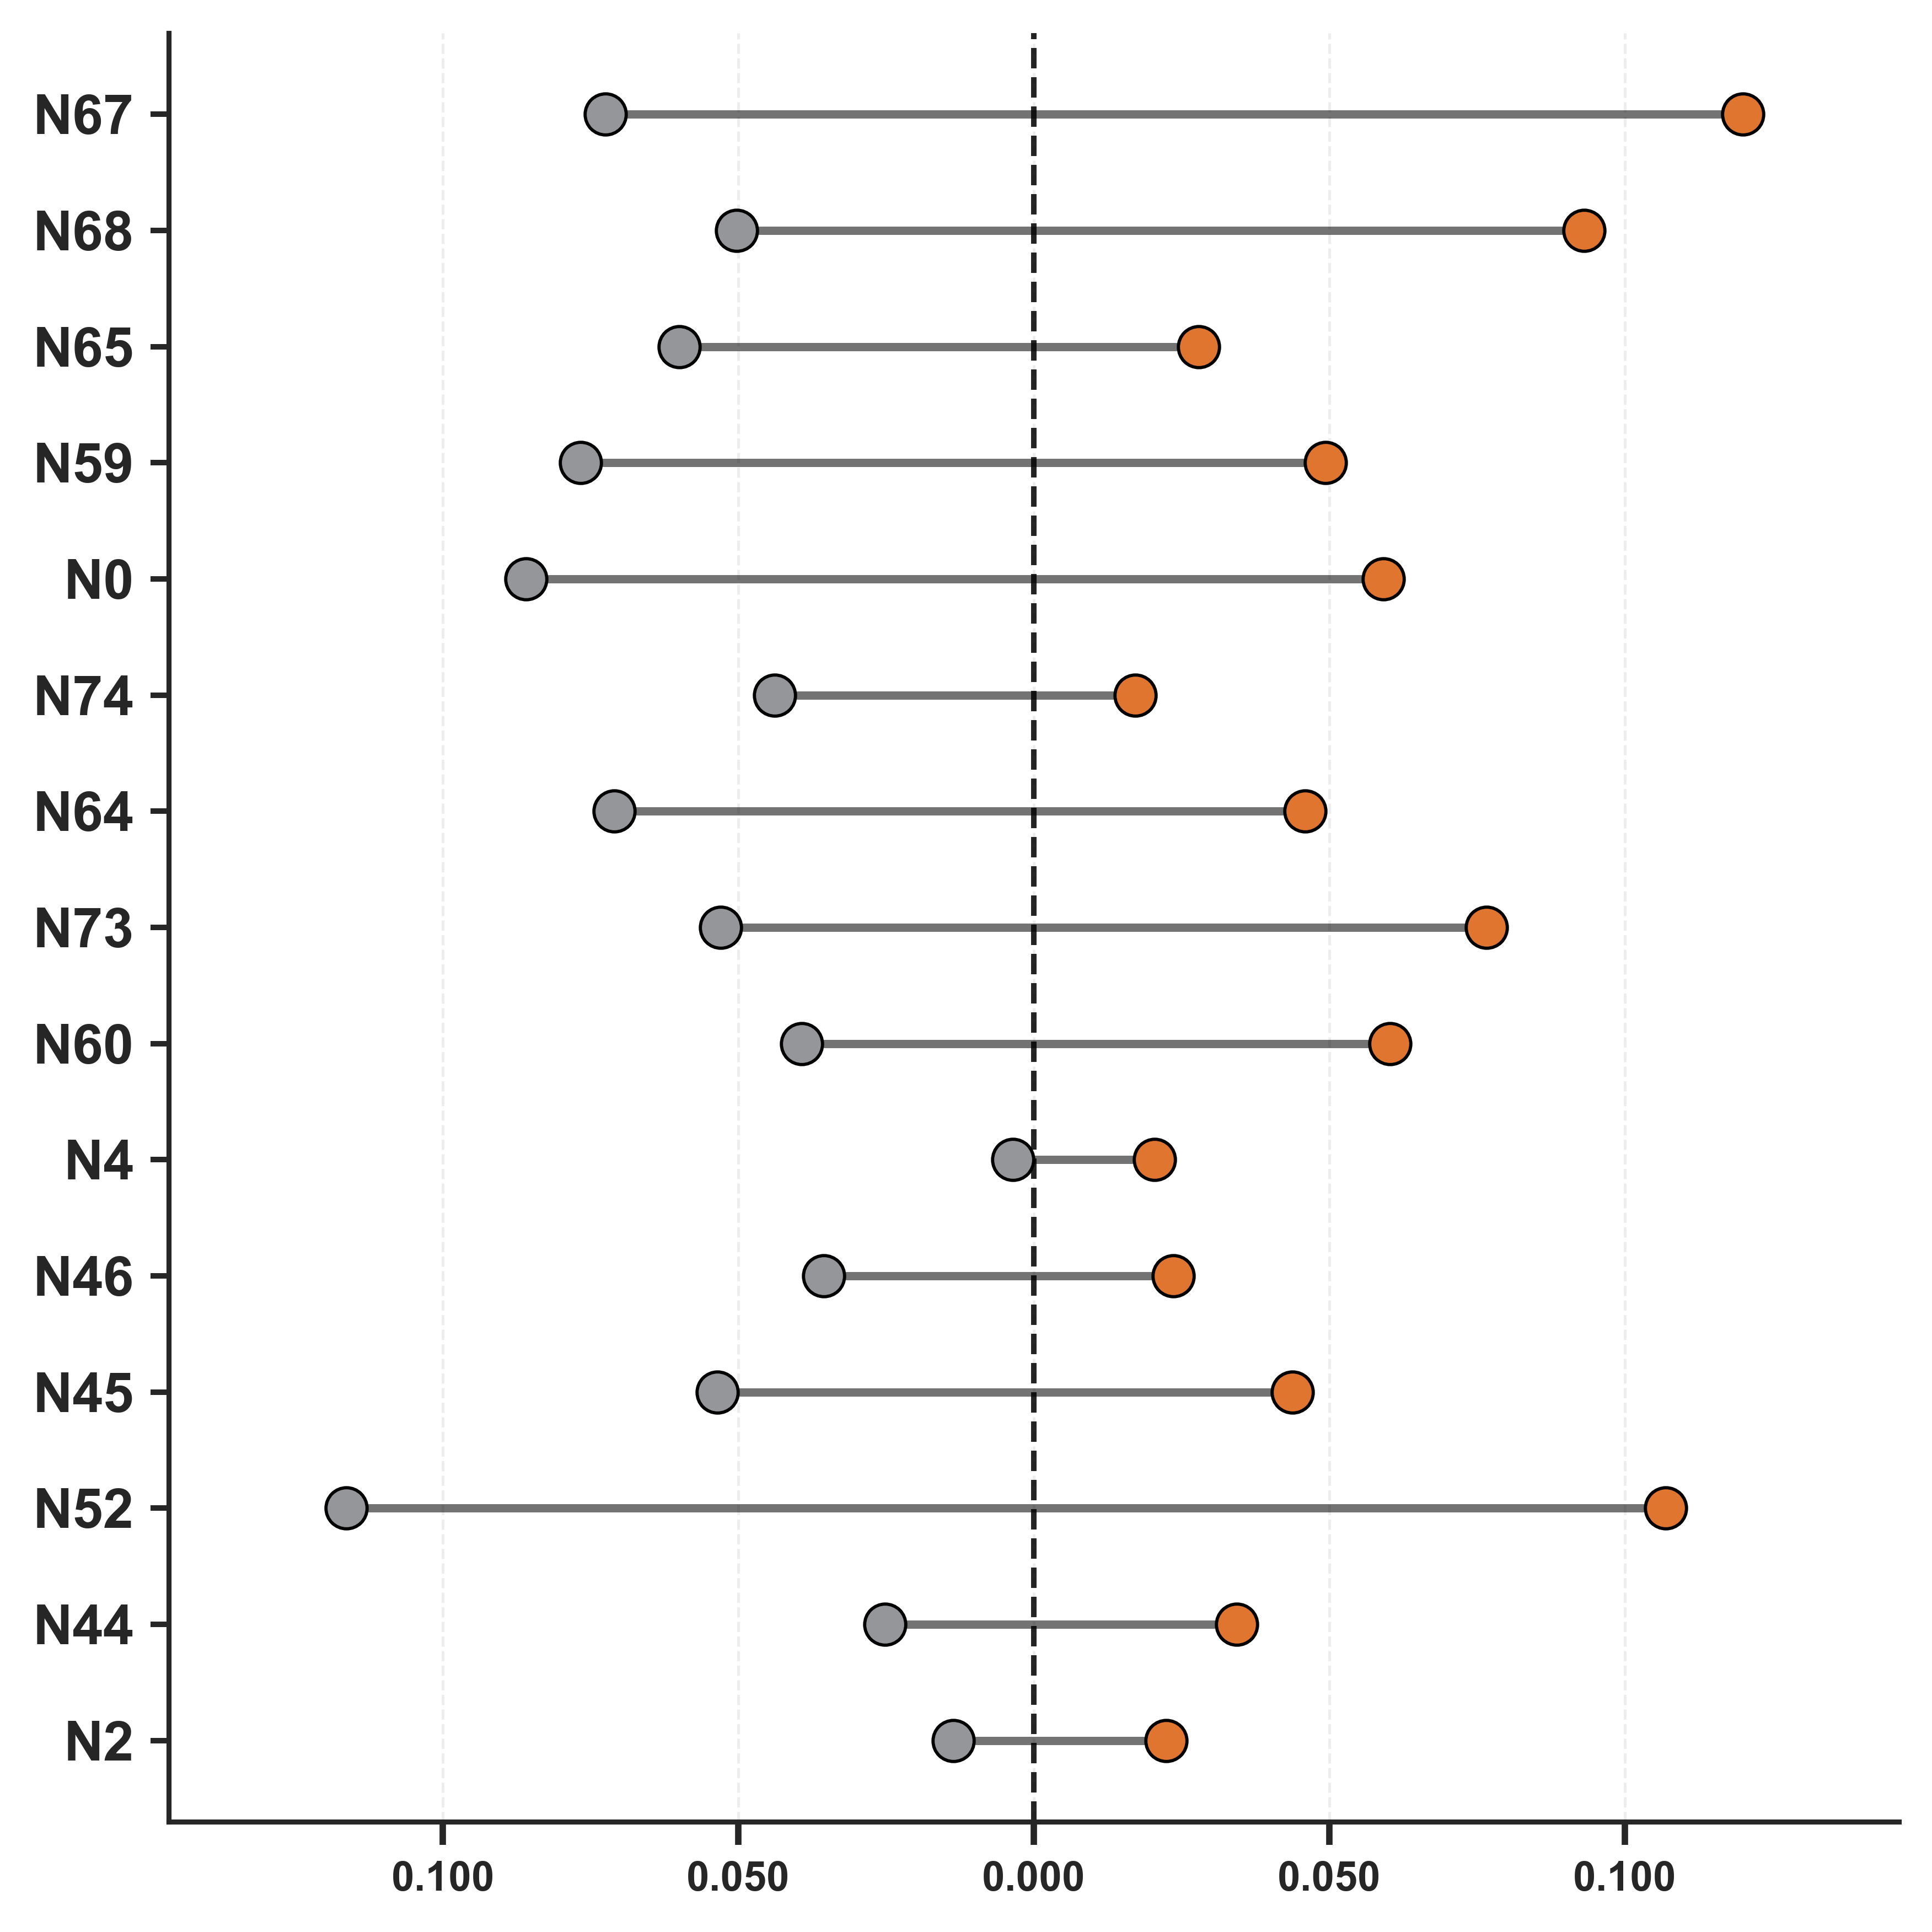

In [95]:
# -*- coding: utf-8 -*-

import os
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter


# ============================================================
# 1. Settings
# ============================================================

plt.rcParams["font.family"] = "Arial"
sns.set_theme(style="white")

OUT_DIR = "./save_figs"
os.makedirs(OUT_DIR, exist_ok=True)

positive_color = "#DF752F"
unlabeled_color = "#949699"

# 只显示差异最大的前20个 node feature
NODE_TOP_K = 15


# ============================================================
# 2. Utility functions
# ============================================================

def to_numpy(x):
    """Convert torch tensor or numpy array to numpy array."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def collect_feature_matrix(dataset, attr_name):
    """
    Collect feature matrices from a PyG-like dataset.

    Parameters
    ----------
    dataset : list
        List of PyG Data objects
    attr_name : str
        "x" for node features
        "edge_attr" for edge features
    """
    feature_list = []

    for data in dataset:
        if not hasattr(data, attr_name):
            continue

        feat = getattr(data, attr_name)
        if feat is None:
            continue

        feat = to_numpy(feat)

        if feat.ndim != 2:
            continue

        feature_list.append(feat)

    if len(feature_list) == 0:
        raise ValueError(f"No valid feature matrix found for {attr_name}")

    return np.concatenate(feature_list, axis=0)


def compute_feature_composition(feature_matrix, eps=1e-12):
    """
    Compute normalized feature composition.

    If features contain negative values, use abs(mean) to avoid cancellation.
    """
    feature_matrix = np.asarray(feature_matrix, dtype=float)

    if np.nanmin(feature_matrix) < 0:
        mean_feat = np.nanmean(np.abs(feature_matrix), axis=0)
    else:
        mean_feat = np.nanmean(feature_matrix, axis=0)

    comp = mean_feat / (np.sum(mean_feat) + eps)

    return mean_feat, comp


def select_top_diff_features(comp_pos, comp_unl, top_k):
    """
    Select top-k feature dimensions with the largest absolute composition difference.
    """
    diff = np.abs(comp_pos - comp_unl)
    selected_idx = np.argsort(diff)[::-1][:top_k]
    return selected_idx


def build_node_feature_df(comp_pos, comp_unl, selected_idx, feature_names=None):
    """
    Build dataframe for node feature mirrored dumbbell plot.
    """
    if feature_names is None:
        feature_names = [f"N{i}" for i in range(len(comp_pos))]

    df = pd.DataFrame({
        "feature": [feature_names[i] for i in selected_idx],
        "positive": comp_pos[selected_idx],
        "unlabeled": comp_unl[selected_idx],
    })

    df["delta"] = df["positive"] - df["unlabeled"]
    df["abs_delta"] = df["delta"].abs()

    # 按绝对差异从大到小排序
    df = df.sort_values("abs_delta", ascending=False).reset_index(drop=True)

    return df


def plot_node_mirrored_dumbbell(ax, df_plot):
    """
    Plot mirrored dumbbell plot for node features only.

    Left  side: Unlabeled composition
    Right side: Positive composition
    """
    n_total = len(df_plot)
    y = np.arange(n_total)

    # 中心虚线
    ax.axvline(0, color="black", linewidth=1.2, linestyle="--", alpha=0.85, zorder=1)

    # mirrored positions
    x_left = -df_plot["unlabeled"].values
    x_right = df_plot["positive"].values

    for i in range(n_total):
        # connector line
        ax.hlines(
            y=i,
            xmin=x_left[i],
            xmax=x_right[i],
            color="black",
            linewidth=1.8,
            alpha=0.55,
            zorder=2
        )

        # unlabeled point
        ax.scatter(
            x_left[i], i,
            s=80,
            c=unlabeled_color,
            edgecolors="black",
            linewidths=0.7,
            marker="o",
            zorder=3
        )

        # positive point
        ax.scatter(
            x_right[i], i,
            s=80,
            c=positive_color,
            edgecolors="black",
            linewidths=0.7,
            marker="o",
            zorder=3
        )

    # y-axis labels
    ax.set_yticks(y)
    ax.set_yticklabels(df_plot["feature"], fontsize=12, fontweight="bold")
    ax.invert_yaxis()

    # x-axis limits
    max_comp = max(df_plot["positive"].max(), df_plot["unlabeled"].max()) * 1.22
    ax.set_xlim(-max_comp, max_comp)

    # x-axis show absolute values
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{abs(x):.3f}"))

    # ax.set_xlabel("Node feature composition", fontsize=11, fontweight="bold")
    ax.set_ylabel("")


    ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.35)

    ax.tick_params(axis="x", labelsize=9, width=1.1, length=3)
    ax.tick_params(axis="y", width=0, length=0)

    ax.tick_params(
        axis="x",
        which="major",
        labelsize=9,
        width=1.4,
        length=5,
        direction="out",
        bottom=True,
        top=False
    )

    # y 轴刻度线：对应每个 feature
    ax.tick_params(
        axis="y",
        which="major",
        width=1.2,
        length=4,
        direction="out",
        left=True,
        right=False
    )

    for label in ax.get_xticklabels():
        label.set_fontweight("bold")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)

    # # direction labels
    # ax.text(
    #     0.22, 1.015, "Unlabeled",
    #     transform=ax.transAxes,
    #     ha="center", va="bottom",
    #     fontsize=10, fontweight="bold",
    #     color=unlabeled_color
    # )

    # ax.text(
    #     0.78, 1.015, "Positive",
    #     transform=ax.transAxes,
    #     ha="center", va="bottom",
    #     fontsize=10, fontweight="bold",
    #     color=positive_color
    # )

    # # legend
    # legend_handles = [
    #     Line2D([0], [0], marker='o', color=positive_color,
    #            markerfacecolor=positive_color, markeredgecolor='black',
    #            markersize=6, linestyle='None', label='Positive composition'),
    #     Line2D([0], [0], marker='o', color=unlabeled_color,
    #            markerfacecolor=unlabeled_color, markeredgecolor='black',
    #            markersize=6, linestyle='None', label='Unlabeled composition'),
    # ]

    # ax.legend(
    #     handles=legend_handles,
    #     loc="lower right",
    #     frameon=False,
    #     fontsize=8.5,
    #     ncol=1,
    #     handlelength=1.2
    # )


# ============================================================
# 3. Collect node features only
# ============================================================

node_pos = collect_feature_matrix(positive_samples, "x")
node_unl = collect_feature_matrix(unlabeled_samples, "x")

print("Node positive shape:", node_pos.shape)
print("Node unlabeled shape:", node_unl.shape)


# ============================================================
# 4. Compute node feature compositions
# ============================================================

node_mean_pos, node_comp_pos = compute_feature_composition(node_pos)
node_mean_unl, node_comp_unl = compute_feature_composition(node_unl)

print("Node feature dimension:", len(node_comp_pos))


# ============================================================
# 5. Select top-20 node features
# ============================================================

node_selected_idx = select_top_diff_features(
    node_comp_pos,
    node_comp_unl,
    top_k=NODE_TOP_K
)

print("Selected top-20 node feature dims:", node_selected_idx)

# 如果你知道真实 feature 名称，可以在这里替换
node_feature_names = [f"N{i}" for i in range(len(node_comp_pos))]

node_df = build_node_feature_df(
    node_comp_pos,
    node_comp_unl,
    node_selected_idx,
    feature_names=node_feature_names
)

print("\nTop 20 node feature shifts:")
print(node_df)


# ============================================================
# 6. Plot
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6), dpi=600)

plot_node_mirrored_dumbbell(ax, node_df)

plt.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "fig2_e.svg"),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

fig2.f

/tmp/ipykernel_418998/3370502891.py:114: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  unlabeled_df = pd.read_csv('../data/searching_space_data_V2.csv')
[17:14:12] WARNING: not removing hydrogen atom without neighbors
[17:14:12] WARNING: not removing hydrogen atom without neighbors
[17:14:12] WARNING: not removing hydrogen atom without neighbors
[17:14:12] WARNING: not removing hydrogen atom without neighbors
[17:14:12] WARNING: not removing hydrogen atom without neighbors


Valid positive SMILES: 126
Valid unlabeled SMILES: 179981
Positive used for plot: 126
Unlabeled used for plot: 30000


[17:14:12] WARNING: not removing hydrogen atom without neighbors
[17:14:13] WARNING: not removing hydrogen atom without neighbors
[17:14:13] WARNING: not removing hydrogen atom without neighbors
[17:14:13] WARNING: not removing hydrogen atom without neighbors
[17:14:13] WARNING: not removing hydrogen atom without neighbors
[17:14:13] WARNING: not removing hydrogen atom without neighbors
[17:14:13] WARNING: not removing hydrogen atom without neighbors
[17:14:13] WARNING: not removing hydrogen atom without neighbors
[17:14:13] WARNING: not removing hydrogen atom without neighbors
[17:14:13] WARNING: not removing hydrogen atom without neighbors
[17:14:13] WARNING: not removing hydrogen atom without neighbors
[17:14:13] WARNING: not removing hydrogen atom without neighbors
[17:14:13] WARNING: not removing hydrogen atom without neighbors
[17:14:13] WARNING: not removing hydrogen atom without neighbors
[17:14:13] WARNING: not removing hydrogen atom without neighbors
[17:14:13] WARNING: not r

Positive fingerprint shape: (126, 2048)
Unlabeled fingerprint shape: (29972, 2048)


/home/hwx/envs/boron/lib/python3.9/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/home/hwx/envs/boron/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/hwx/envs/boron/lib/python3.9/site-packages/pynndescent/pynndescent_.py:939: UserWarning: Failed to correctly find n_neighbors for some samples. Results may be less than ideal. Try re-running with different parameters.
  warn(


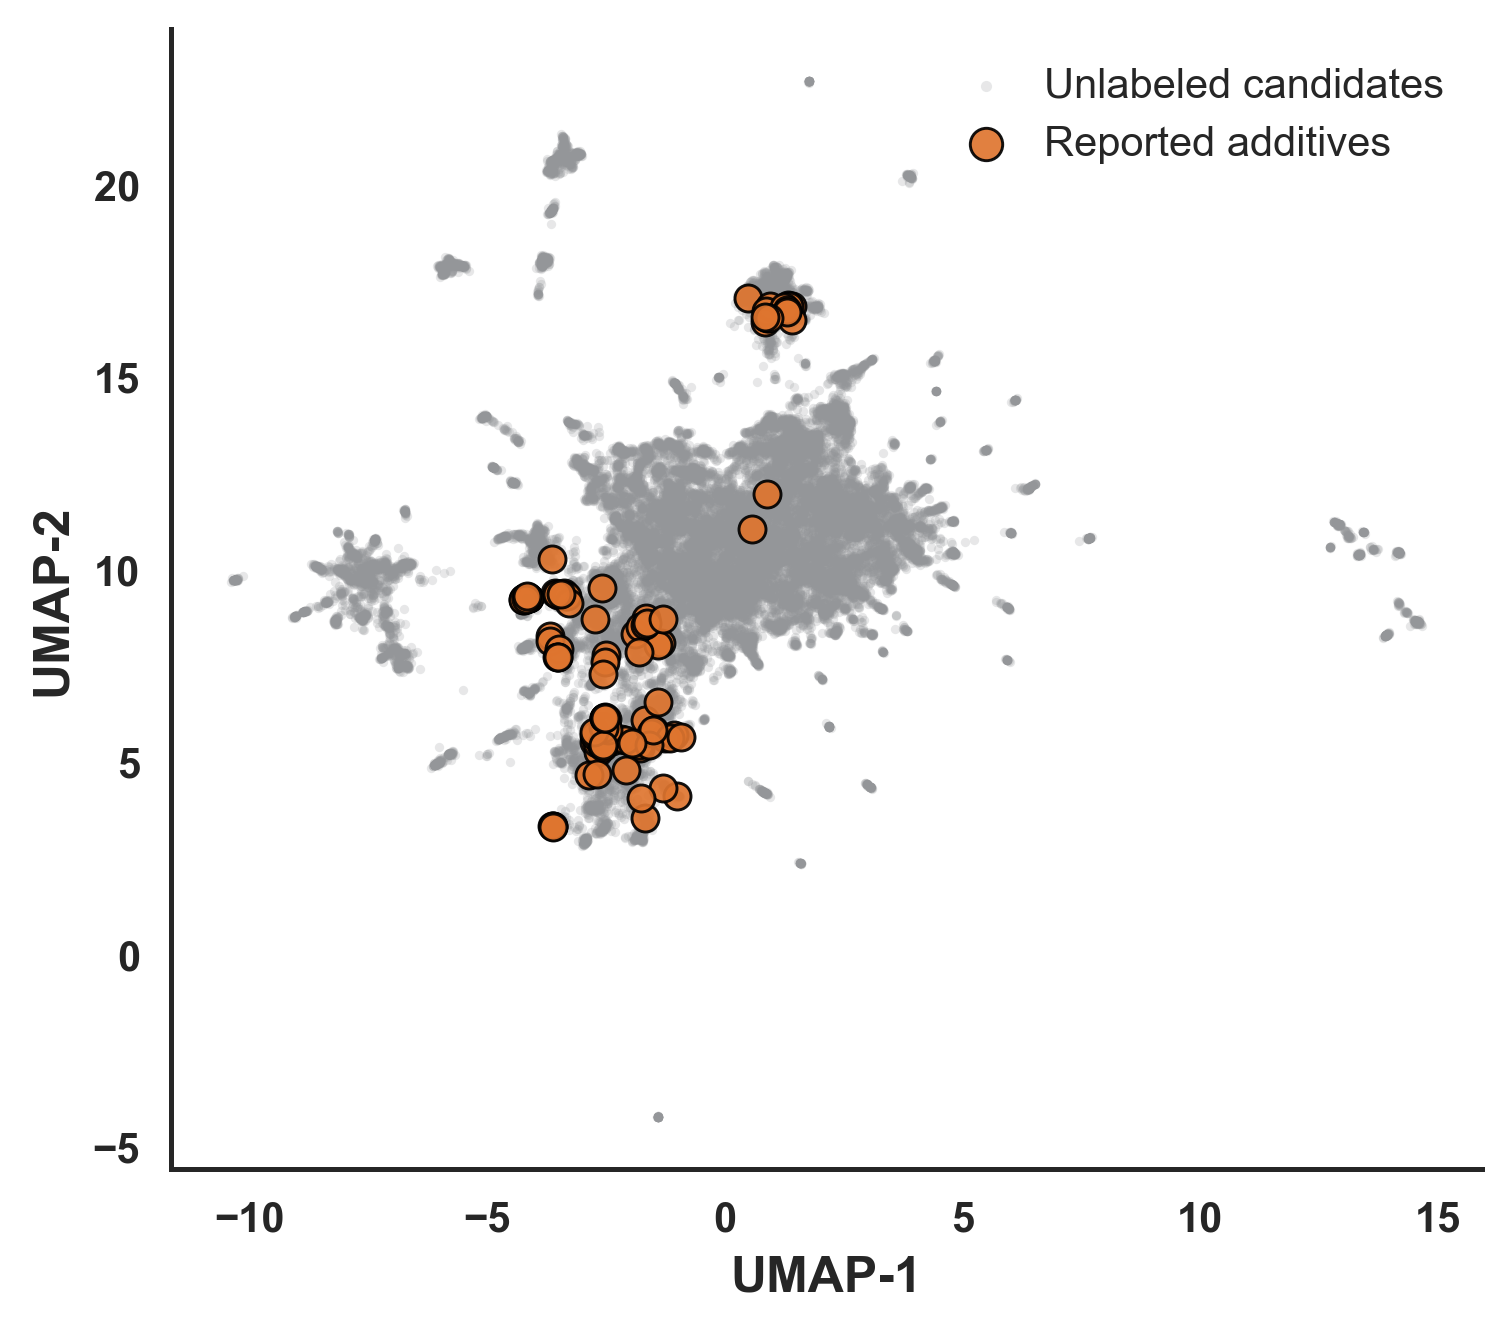

In [97]:
# -*- coding: utf-8 -*-

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs

from sklearn.decomposition import PCA

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("Warning: umap-learn is not installed. PCA will be used instead.")
    print("You can install UMAP by: pip install umap-learn")


# ============================================================
# 1. Settings
# ============================================================

plt.rcParams["font.family"] = "Arial"
sns.set_theme(style="white")

OUT_DIR = "./save_figs"
os.makedirs(OUT_DIR, exist_ok=True)

positive_color = "#DF752F"
unlabeled_color = "#949699"

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Morgan fingerprint parameters
MORGAN_RADIUS = 2
MORGAN_NBITS = 2048

# 如果 unlabeled 太多，建议抽样，否则 UMAP 会比较慢
MAX_UNLABELED_FOR_UMAP = 30000

# 如果 positive 只有 126 个，建议全部保留
MAX_POSITIVE_FOR_UMAP = None


# ============================================================
# 2. Extract SMILES
# ============================================================

def get_smiles_from_data(data):
    """
    Try to extract SMILES from a PyG Data object.
    Modify this function if your SMILES field has a different name.
    """

    candidate_attrs = [
        "smiles",
        "smi",
        "SMILES",
        "canonical_smiles",
        "mol_smiles",
    ]

    for attr in candidate_attrs:
        if hasattr(data, attr):
            smi = getattr(data, attr)

            # Some datasets store smiles as list/tuple with one element
            if isinstance(smi, (list, tuple)):
                smi = smi[0]

            # Some datasets store smiles as bytes
            if isinstance(smi, bytes):
                smi = smi.decode("utf-8")

            return str(smi)

    raise AttributeError(
        "Cannot find SMILES in Data object. "
        "Please check whether your data has attributes like data.smiles or data.smi."
    )


def extract_smiles_list(dataset):
    smiles_list = []

    for data in dataset:
        try:
            smi = get_smiles_from_data(data)
            mol = Chem.MolFromSmiles(smi)

            if mol is not None:
                smiles_list.append(Chem.MolToSmiles(mol))
        except Exception:
            continue

    return smiles_list



unlabeled_smiles = extract_smiles_list(unlabeled_samples)

with open('../data/additives.json', 'r') as file:
    additives_data = json.load(file)
        
positive_smiles = [i['smiles'] for i in additives_data.values()]

unlabeled_df = pd.read_csv('../data/searching_space_data_V2.csv')
unlabeled_smiles = unlabeled_df['SMILES'].tolist()

print("Valid positive SMILES:", len(positive_smiles))
print("Valid unlabeled SMILES:", len(unlabeled_smiles))


# ============================================================
# 3. Optional sampling
# ============================================================

def random_sample_list(x, max_n=None, seed=42):
    if max_n is None or len(x) <= max_n:
        return x

    rng = random.Random(seed)
    return rng.sample(x, max_n)


positive_smiles_plot = random_sample_list(
    positive_smiles,
    max_n=MAX_POSITIVE_FOR_UMAP,
    seed=RANDOM_SEED
)

unlabeled_smiles_plot = random_sample_list(
    unlabeled_smiles,
    max_n=MAX_UNLABELED_FOR_UMAP,
    seed=RANDOM_SEED
)

print("Positive used for plot:", len(positive_smiles_plot))
print("Unlabeled used for plot:", len(unlabeled_smiles_plot))


# ============================================================
# 4. Morgan fingerprint
# ============================================================

def smiles_to_morgan_fp(smiles_list, radius=2, n_bits=2048):
    """
    Convert SMILES to Morgan fingerprint matrix.
    """

    generator = rdFingerprintGenerator.GetMorganGenerator(
        radius=radius,
        fpSize=n_bits
    )

    fps = []
    valid_smiles = []

    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)

        if mol is None:
            continue

        fp = generator.GetFingerprint(mol)
        arr = np.zeros((n_bits,), dtype=np.float32)
        DataStructs.ConvertToNumpyArray(fp, arr)

        fps.append(arr)
        valid_smiles.append(smi)

    if len(fps) == 0:
        raise ValueError("No valid fingerprints generated.")

    return np.asarray(fps, dtype=np.float32), valid_smiles


fp_pos, positive_smiles_plot = smiles_to_morgan_fp(
    positive_smiles_plot,
    radius=MORGAN_RADIUS,
    n_bits=MORGAN_NBITS
)

fp_unl, unlabeled_smiles_plot = smiles_to_morgan_fp(
    unlabeled_smiles_plot,
    radius=MORGAN_RADIUS,
    n_bits=MORGAN_NBITS
)

print("Positive fingerprint shape:", fp_pos.shape)
print("Unlabeled fingerprint shape:", fp_unl.shape)


# ============================================================
# 5. Dimensionality reduction
# ============================================================

X = np.vstack([fp_pos, fp_unl])

labels = np.array(
    ["Positive"] * len(fp_pos) +
    ["Unlabeled"] * len(fp_unl)
)

if HAS_UMAP:
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.15,
        metric="jaccard",
        random_state=RANDOM_SEED,
        low_memory=True
    )

    embedding = reducer.fit_transform(X.astype(bool))

    method_name = "UMAP"

else:
    reducer = PCA(n_components=2, random_state=RANDOM_SEED)
    embedding = reducer.fit_transform(X)

    method_name = "PCA"


emb_pos = embedding[labels == "Positive"]
emb_unl = embedding[labels == "Unlabeled"]


# ============================================================
# 6. Plot
# ============================================================

fig, ax = plt.subplots(figsize=(5.2, 4.6), dpi=300)

# Unlabeled background
ax.scatter(
    emb_unl[:, 0],
    emb_unl[:, 1],
    s=5,
    c=unlabeled_color,
    alpha=0.22,
    linewidths=0,
    rasterized=True,
    label="Unlabeled candidates"
)

# Positive samples
ax.scatter(
    emb_pos[:, 0],
    emb_pos[:, 1],
    s=42,
    c=positive_color,
    alpha=0.92,
    edgecolors="black",
    linewidths=0.7,
    label="Reported additives",
    zorder=3
)

# Style
ax.set_xlabel(f"{method_name}-1", fontsize=12, fontweight="bold")
ax.set_ylabel(f"{method_name}-2", fontsize=12, fontweight="bold")

ax.tick_params(
    axis="both",
    labelsize=10,
    width=1.2,
    length=4,
    direction="out"
)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ax.legend(
    loc="best",
    frameon=False,
    fontsize=10,
    markerscale=1.2,
    handletextpad=0.4
)

plt.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "fig2_f.svg"),
    dpi=600,
    bbox_inches="tight"
)

plt.show()